# Laboratorio 10

**Grupo:**
- Juan Caros Ticlia Maqui
- Jose Daniel Huaman Rosales
- Paulo Isael Miranda Barrientos

---
## P0

In [46]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rtree import index
import face_recognition
import psycopg2
import time

DATASET_PATH = "/home/tkaos/UTEC/C5/bd2/sol/data/lfw_funneled"

In [47]:
coleccion = []
for path in glob.iglob(os.path.join(DATASET_PATH, "**", "*.jpg")):
    person = path.split("/")[-2]
    coleccion.append({"person": person, "path": path})

coleccion = pd.DataFrame(coleccion)
print(f"Total de imagenes: {len(coleccion)}")

Total de imagenes: 13233


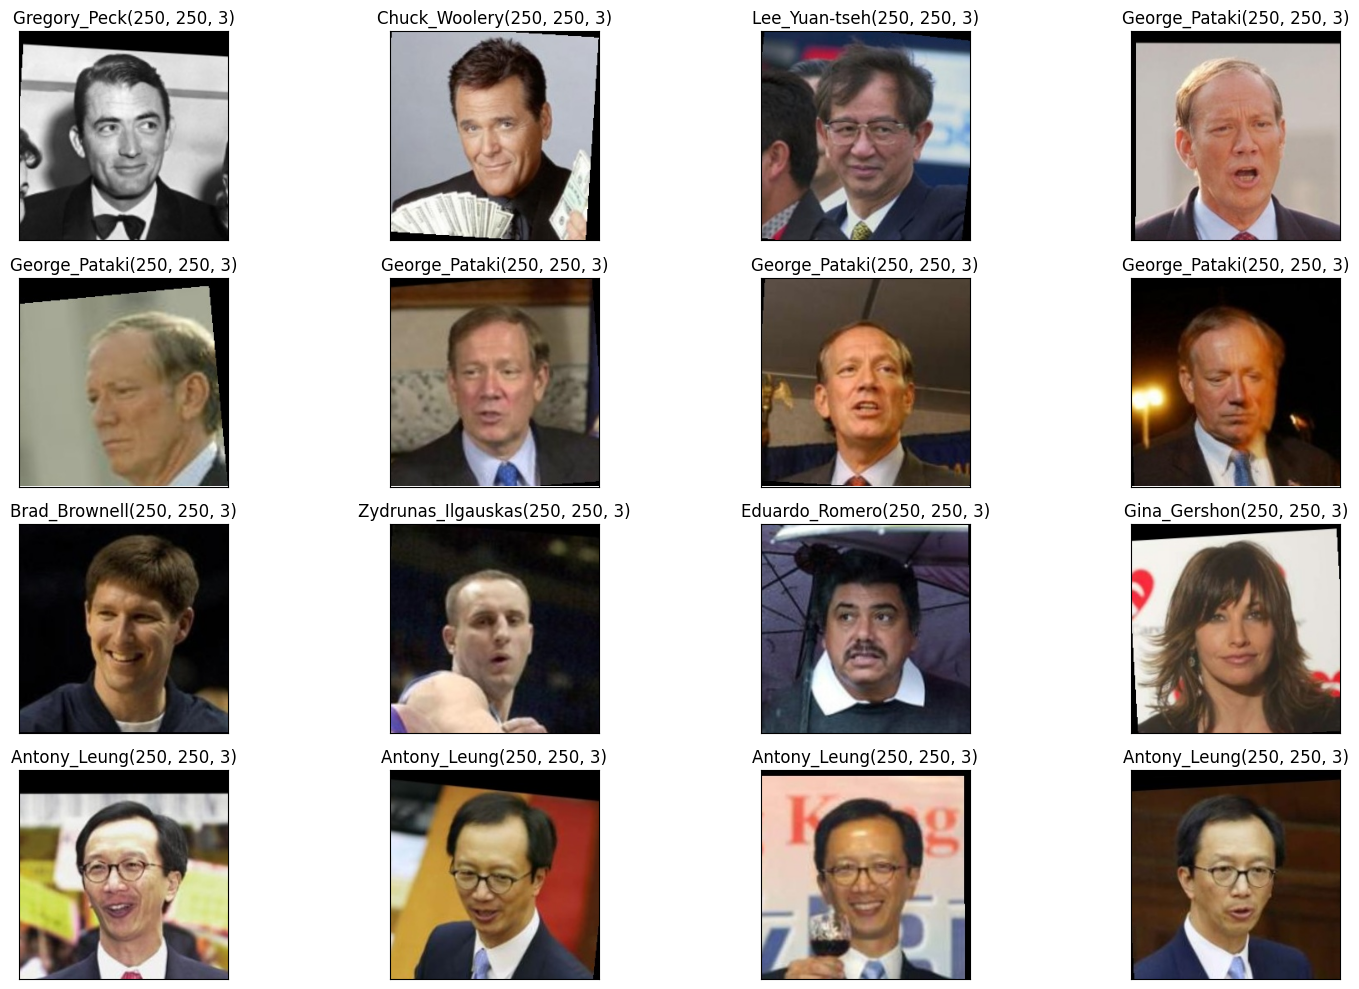

In [48]:
def mostrarFotos(coleccion, posiciones):
    plt.figure(figsize=(16, 10))
    i = 0
    for idx in posiciones:
        img = plt.imread(coleccion.path.iloc[idx])
        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.title(coleccion.person.iloc[idx] + str(img.shape))
        plt.xticks([])
        plt.yticks([])
        i += 1
    plt.tight_layout()
    plt.show()

posiciones = list(range(0, 16))
mostrarFotos(coleccion, posiciones)

In [49]:
conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password="123456",
    host="localhost",
    port="5433"
)
cur = conn.cursor()

cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
cur.execute("""
    CREATE TABLE IF NOT EXISTS face_embeddings (
        id SERIAL PRIMARY KEY,
        name TEXT,
        path TEXT,
        embedding VECTOR(128)
    );
""")
conn.commit()
print("Extension vector habilitada y tabla face_embeddings lista.")

Extension vector habilitada y tabla face_embeddings lista.


---
## P1

In [51]:
def generate_face_embeddings(colecion_df, N, cursor):
    rostros_procesados = 0
    for index, row in colecion_df.iterrows():
        if rostros_procesados >= N:
            break
        nombre = row["person"]
        ruta = row["path"]
        try:
            image = face_recognition.load_image_file(ruta)
            face_encodings = face_recognition.face_encodings(image)
            if face_encodings:
                cursor.execute(
                    "INSERT INTO face_embeddings (name, path, embedding) VALUES (%s, %s, %s)",
                    (nombre, ruta, face_encodings[0].tolist())
                )
                rostros_procesados += 1
                print(f"Rostro {rostros_procesados}/{N} guardado: {nombre}")
            else:
                print(f"Sin rostro: {ruta}")
        except Exception as e:
            print(f"Error: {e}")
    conn.commit()
    print(f"\nProcesados {rostros_procesados} rostros.")
    generate_face_embeddings(coleccion, 100, cur)

---
## P2

In [52]:
cur.execute("SELECT name, path, embedding::text FROM face_embeddings;")
rows = cur.fetchall()

embeddings_list = []
for name, path, emb_text in rows:
    emb_str = emb_text.replace('[', '').replace(']', '').replace(',', ' ')
    emb_array = np.fromstring(emb_str, sep=' ')
    embeddings_list.append({'person': name, 'path': path, 'embedding': emb_array})

print(f"Embeddings cargados: {len(embeddings_list)}")

Embeddings cargados: 403


In [53]:
def knn_lineal(q, embeddings_data, k=5, metrica='euclidiana'):
    distancias = []
    for item in embeddings_data:
        v = item['embedding']
        if metrica == 'euclidiana':
            dist = np.linalg.norm(q - v)
        elif metrica == 'coseno':
            cos_sim = np.dot(q, v) / (np.linalg.norm(q) * np.linalg.norm(v))
            dist = 1 - cos_sim
        distancias.append((item['person'], item['path'], dist))
    distancias.sort(key=lambda x: x[2])
    return distancias[:k]

In [54]:
QUERY_IMAGE = "jose.jpeg"

if os.path.exists(QUERY_IMAGE):
    img = face_recognition.load_image_file(QUERY_IMAGE)
    encodings = face_recognition.face_encodings(img)
    if encodings:
        q = encodings[0]
        print("Embedding de consulta generado.")

        t0 = time.time()
        r_euc = knn_lineal(q, embeddings_list, k=5, metrica='euclidiana')
        t1 = time.time()
        r_cos = knn_lineal(q, embeddings_list, k=5, metrica='coseno')
        t2 = time.time()

        print(f"KNN Euclidiana - Tiempo: {t1-t0:.4f}s")
        for p, _, d in r_euc:
            print(f"  {p}: {d:.6f}")
        print(f"KNN Coseno - Tiempo: {t2-t1:.4f}s")
        for p, _, d in r_cos:
            print(f"  {p}: {d:.6f}")
    else:
        print("No se detecto rostro.")
else:
    print(f"Imagen no encontrada: {QUERY_IMAGE}")

Embedding de consulta generado.
KNN Euclidiana - Tiempo: 0.0009s
  Lee_Yuan-tseh: 0.606602
  Lee_Yuan-tseh: 0.606602
  Lee_Yuan-tseh: 0.606602
  Lee_Yuan-tseh: 0.606602
  Antony_Leung: 0.681518
KNN Coseno - Tiempo: 0.0010s
  Lee_Yuan-tseh: 0.097180
  Lee_Yuan-tseh: 0.097180
  Lee_Yuan-tseh: 0.097180
  Lee_Yuan-tseh: 0.097180
  Antony_Leung: 0.120443


---
## P3

In [56]:
if os.path.exists(QUERY_IMAGE) and 'q' in locals():
    q_str = "[" + ",".join(str(x) for x in q) + "]"

    cur.execute("DROP INDEX IF EXISTS face_embedding_euc_idx;")
    cur.execute("CREATE INDEX face_embedding_euc_idx ON face_embeddings USING ivfflat (embedding vector_l2_ops) WITH (lists = 100);")
    cur.execute("DROP INDEX IF EXISTS face_embedding_cos_idx;")
    cur.execute("CREATE INDEX face_embedding_cos_idx ON face_embeddings USING ivfflat (embedding vector_cosine_ops) WITH (lists = 100);")
    conn.commit()
    print("Indices IVFFlat creados.")

    cur.execute("SET ivfflat.probes = 10;")

    t0 = time.time()
    cur.execute(f"SELECT id, name, embedding <-> '{q_str}' AS distance FROM face_embeddings ORDER BY embedding <-> '{q_str}' LIMIT 5;")
    r_euc = cur.fetchall()
    t1 = time.time()
    print(f"IVFFlat Euclidiana - Tiempo: {t1-t0:.4f}s")
    for row in r_euc:
        print(f"  {row[1]}: {row[2]:.6f}")

    t0 = time.time()
    cur.execute(f"SELECT id, name, embedding <=> '{q_str}' AS distance FROM face_embeddings ORDER BY embedding <=> '{q_str}' LIMIT 5;")
    r_cos = cur.fetchall()
    t1 = time.time()
    print(f"IVFFlat Coseno - Tiempo: {t1-t0:.4f}s")
    for row in r_cos:
        print(f"  {row[1]}: {row[2]:.6f}")

    cur.execute("DROP INDEX IF EXISTS face_embedding_hnsw_idx;")
    cur.execute("CREATE INDEX face_embedding_hnsw_idx ON face_embeddings USING hnsw (embedding vector_l2_ops) WITH (m = 16, ef_construction = 200);")
    conn.commit()
    print("\nIndice HNSW creado.")

    cur.execute("SET hnsw.ef_search = 50;")
    t0 = time.time()
    cur.execute(f"SELECT id, name, embedding <-> '{q_str}' AS distance FROM face_embeddings ORDER BY embedding <-> '{q_str}' LIMIT 5;")
    r_hnsw = cur.fetchall()
    t1 = time.time()
    print(f"HNSW Euclidiana - Tiempo: {t1-t0:.4f}s")
    for row in r_hnsw:
        print(f"  {row[1]}: {row[2]:.6f}")
else:
    print("Ejecuta primero la celda de consulta en P2.")

Indices IVFFlat creados.
IVFFlat Euclidiana - Tiempo: 0.0006s
  Lee_Yuan-tseh: 0.606601
  Lee_Yuan-tseh: 0.606601
  Lee_Yuan-tseh: 0.606601
  Lee_Yuan-tseh: 0.606601
  Antony_Leung: 0.681518
IVFFlat Coseno - Tiempo: 0.0003s
  Lee_Yuan-tseh: 0.097180
  Lee_Yuan-tseh: 0.097180
  Lee_Yuan-tseh: 0.097180
  Lee_Yuan-tseh: 0.097180
  Antony_Leung: 0.120443

Indice HNSW creado.
HNSW Euclidiana - Tiempo: 0.0007s
  Lee_Yuan-tseh: 0.606601
  Lee_Yuan-tseh: 0.606601
  Lee_Yuan-tseh: 0.606601
  Lee_Yuan-tseh: 0.606601
  Antony_Leung: 0.681518


---
## P4: Analisis comparativo y conclusiones

#### Metodología de prueba
 - Se dividieron en dataset de tamaños `1000`, `2000`, `4000`, `8000` y `12000`.
 - Para el KNN se extrajeron loas Top-100, es decir, `KNN = 100`.
 - Se usó la **distancia coseno** (`vector_cosine_ops`).
 - Para el índice `IVF` se toman los siguientes parámetros: `ivfflat.probes = 10` y `lists = 100`.
 - Para el índice `HNSW` se toman los siguientes parámetros: `hnsw.ef_search = 100` y `m = 40`.
 - Para comparar los resultados dados por los índices contra el barrido lineal de KNN se toma en cuenta si el nombre en la `i-ésima` posición es el mismo.

Imagen de referencia con los resultados del barrido lineal con mil elementos en la primera fila y 12 mil elementos en la segunda.

![Imagen de referencia](img/knn_lineal.png)

Como colocar 100 imágenes puede ser algo extenso, decidimos usar regla de comparación previamente definida. Los resultados dados por los índices los comparamos con los resultados del KNN de barrido lineal; si en la posición `i` son el mismo, se consideran como match.

La gráfica a continuación muestra en porcentajes los match que hubo para los distintos tamaños de registros. Y también cómo se ven comparando los 5, 10, 25, 50 y 100 primeros resultados.

![Comparativa Solapamiento](img/solapamiento.png)

Sin duda alguna, según los resultados obtenidos, el índice **HNSW** se aproxima mucho más al resultado exacto obtenido mediante búsqueda KNN por barrido lineal. Esto se evidencia en el porcentaje de *match* o solapamiento, que se mantiene cercano al 100% en todos los tamaños de dataset evaluados. Además, para consultas **Top-5**, ambos índices alcanzan un *match* del 100%; sin embargo, a medida que aumenta el número de resultados recuperados, HNSW conserva una mayor fidelidad respecto al KNN exacto. Si bien **IVF** intenta mantener una fidelidad alta, solo lo logra para **Top-k** pequeños, mientras mayor sea el número de vecinos, su porcentaje de match es menor.

Este comportamiento puede explicarse porque, mientras **IVF** restringe la búsqueda a un conjunto de clústeres seleccionados previamente (`lists = 100`, `probes = 10`), **HNSW** navega un grafo de vecinos cercanos (`m = 40`, `ef_search = 100`), lo que le permite explorar de manera más flexible el espacio vectorial y reducir la probabilidad de omitir vecinos relevantes. Por ello, bajo las condiciones evaluadas, HNSW demuestra una mayor capacidad para reproducir los resultados de la búsqueda exacta, manteniendo un nivel de precisión superior conforme crece el número de elementos recuperados.

##### ¿En qué se diferencia un barrido lineal de PgVector?

Se debe a que los índices probados, son índices de búsqueda aproximada. A diferencia del KNN lineal que literalmente hace un barrido y comprueba todos los valores posibles. Los índices de búsqueda aproximada sacrifican la extactitud por la eficiencia. Esto lo evidenciaremos a continuación con la comparación de tiempos en la búsqueda.

#### Comparación de tiempos

![Comparativa de tiempos](img/comparativa_tiempos.png)

En el gráfico de la izquierda se muestra el tiempo de consulta para búsquedas **Top-K = 100** utilizando tanto un barrido lineal como los índices evaluados. Se observa que el tiempo del barrido lineal crece de forma aproximadamente lineal conforme aumenta el tamaño del dataset, mientras que los índices mantienen tiempos de respuesta prácticamente constantes en comparación.

Para el caso de un dataset de 12 000 registros, el barrido lineal alcanza un tiempo aproximado de **65 ms**, mientras que ambos índices permanecen por debajo de **0.9 ms**. Esto representa una mejora de aproximadamente **70 veces** en el tiempo de respuesta respecto a la búsqueda exacta por barrido lineal.

Dado que la diferencia de magnitud entre ambos enfoques dificulta observar el comportamiento detallado de los índices, en el gráfico de la derecha se presenta una vista ampliada que permite una comparación más precisa. En este se observa que **HNSW** presenta tiempos de consulta ligeramente mayores a **IVF**, lo cual se explica porque HNSW mantiene y explora un conjunto más amplio de candidatos durante la búsqueda (`ef_search = 100`), incrementando el número de evaluaciones para mejorar la calidad de los resultados.

### Conclusiones

#### Ventajas y desventajas de cada método

- **KNN Lineal**: método exacto que recorre todos los vectores, garantizando 100% de precisión. Su principal desventaja es la complejidad O(n), lo que lo hace poco escalable para grandes volúmenes de datos.

- **IVF (Inverted File Index)**: divide el espacio vectorial en clústeres y reduce la búsqueda a los más cercanos (`lists = 100`, `probes = 10`). Es eficiente y rápido, pero su precisión depende fuertemente del número de *probes*. En los experimentos, mostró buen desempeño para *k* bajos, pero una caída de recall en **Top-100 (~60%)**, con variaciones según el tamaño del dataset.

- **HNSW**: utiliza un grafo navegable jerárquico que permite una búsqueda más global (`m = 40`, `ef_search = 100`). Presentó la mayor fidelidad, con solapamiento cercano al 100% incluso en Top-100. Su principal desventaja es el mayor consumo de memoria y la sensibilidad a parámetros.

| Método | Ventajas | Desventajas |
| ------ | -------- | ----------- |
| **KNN Lineal** | Exacto y simple | No escala (O(n)) |
| **IVF Flat** | Rápido y ligero | Menor recall en Top-K altos |
| **HNSW** | Alta precisión y consistencia | Mayor uso de memoria |

#### Escalabilidad

Ambos índices (IVF y HNSW) mantienen tiempos de consulta casi constantes al aumentar el tamaño del dataset (1k → 12k), mientras que el KNN Lineal crece de forma lineal.

Para 12 000 registros, los índices permanecen por debajo de ~0.9 ms, mientras que el barrido lineal alcanza ~65 ms, lo que representa una mejora aproximada de **70×**.

Sin embargo, HNSW tiende a ser ligeramente más lento que IVF debido a que explora un mayor número de candidatos durante la búsqueda (`ef_search`), aunque mantiene mejor calidad de resultados.

#### Conclusión de fidelidad (HNSW vs IVF)

HNSW mostró una fidelidad casi perfecta frente al KNN exacto, incluso en valores altos de Top-K, probablemente influenciado por el uso de `ef_search = 100`, que incrementa la exploración del grafo. IVF, en cambio, mantuvo una alta precisión en Top-K pequeños, pero su recall disminuyó progresivamente al aumentar el número de vecinos recuperados, especialmente en Top-100.

#### Casos de uso en la vida real

- **Sistemas de recomendación**: plataformas como Netflix o Spotify utilizan embeddings para sugerir contenido basado en similitud entre usuarios o items.
- **Búsqueda semántica (RAG)**: motores de búsqueda y asistentes con LLMs recuperan documentos relevantes antes de generar respuestas.
- **Detección de fraude**: comparación de transacciones en tiempo real para identificar patrones anómalos similares a casos conocidos.
- **Bioinformática**: búsqueda de secuencias genéticas o estructuras de proteínas similares en bases de datos masivas.
- **Deduplicación de datos**: detección de registros o documentos duplicados en grandes repositorios.

---
## Cerrar conexion

In [45]:
cur.close()
conn.close()
print("Conexion cerrada.")

Conexion cerrada.
